<a href="https://colab.research.google.com/github/IsuPaul/Indpendent-Research/blob/IR_Codes/IR_Source_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ENHANCED MACHINE LEARNING MODEL FOR 3D PRINTING CONCRETE COMPRESSIVE STRENGTH PREDICTION

## Imports

In [1]:
import pandas as pd
import numpy as np
import xgboost as xbt
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import shap
import io
from sklearn.utils import resample
from sklearn.preprocessing import scale
from sklearn.tree import DecisionTreeRegressor
from sklearn import svm
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RepeatedKFold
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
from sklearn.inspection import PartialDependenceDisplay
from google.colab import files


## DATA MANAGEMENT AND CLEANING

### Visualization and Description of Uncleaned Data

In [2]:
df = pd.read_csv('Datasets.csv', encoding='latin-1')

In [3]:
#df.head()

In [4]:
#df.describe()

### Determining the type of data in each column

In [5]:
#df.dtypes

### Converting all data to float

In [6]:
df['Carbonated RFA (Kg)']=df['Carbonated RFA (Kg)'].astype(float)
df['PP (Kg)']=df['PP (Kg)'].astype(float)
df['Silica Powder (Kg)']=df['Silica Powder (Kg)'].astype(float)
df['AT (Kg)']=df['AT (Kg)'].astype(float)
#df.dtypes

### Checking for missing data

In [7]:
#df.isnull().sum()

### Fixing Missing Data

In [8]:
imputer_gbt = IterativeImputer(max_iter=10, random_state=42)
imputed_data=imputer_gbt.fit_transform(df)
imputed_data = np.maximum(imputed_data, 0)
imputed_df=pd.DataFrame(imputed_data,columns=df.columns)

### Reconfirm to check for missing data

In [9]:
#imputed_df.isnull().sum()

### Features Distributions

In [10]:
for i in imputed_df.columns:
    plt.figure(figsize=(2.5, 2.5))
    plt.hist(imputed_df[i])
    plt.xlabel(f"{i}",fontsize=7)
    plt.ylabel("Frequency",fontsize=7)
    plt.title(" ")
    plt.tight_layout()
    plt.savefig(f"{i.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')}.jpg")
    plt.close('all')

## MODEL DEVELOPEMENTS

#### Assigning Variables

In [11]:
X=imputed_df.drop('Compressive Strength (MPa)',axis=1).copy()
y=imputed_df['Compressive Strength (MPa)'].copy()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42)

#### Scaling the dataframe and assigning variables for SVM

In [13]:
sdf=(imputed_df-imputed_df.min())/(imputed_df.max()-imputed_df.min())
X_svm=sdf.drop('Compressive Strength (MPa)',axis=1).copy()
y_svm=sdf['Compressive Strength (MPa)'].copy()
Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_svm, y_svm, test_size=0.3,random_state=42)

#### Hyperparameter Tunning of Models
Double-click the below cell, copy, and paste in a code field.

param_grids = {
    'XGBoost': {'learning_rate': [0.1, 0.2], 'max_depth': [1,3,4,], 'n_estimators': [500, 1000]},
    'SVM': {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['rbf']},
    'RandomForest': {'n_estimators': [100, 200], 'max_depth': [10, 20, None]},
    'DecisionTree': {'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]},
    'KNN': {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
}

###### Models to optimize (Linear Regression doesn't typically need grid search for basic form)
models_to_tune = {
    'XGBoost': xbt.XGBRegressor(random_state=42),
    'SVM': svm.SVR(),
    'RandomForest': RandomForestRegressor(random_state=42),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'KNN': KNeighborsRegressor()
}

optimized_models = {}

####### 2. Optimization and Evaluation Loop
for name, model in models_to_tune.items():
    print(f'Optimizing {name}...')
    current_X_train = Xs_train if name == 'SVM' else X_train
    current_y_train = ys_train if name == 'SVM' else y_train
    current_X_test = Xs_test if name == 'SVM' else X_test
    current_y_test = ys_test if name == 'SVM' else y_test

    grid = GridSearchCV(model, param_grids[name], cv=10, scoring='neg_mean_squared_error', n_jobs=-1)
    grid.fit(current_X_train, current_y_train)
    best_model = grid.best_estimator_
    optimized_models[name] = best_model
    
    print(f'Best Params for {name}: {grid.best_params_}')

    for data_name, cur_X, cur_y in [('Train', current_X_train, current_y_train), ('Test', current_X_test, current_y_test)]:
        preds = best_model.predict(cur_X)
        mse = mean_squared_error(cur_y, preds)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(cur_y, preds)
        r2 = r2_score(cur_y, preds)
        print(f'{name} {data_name} -> MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}')

### EXTREME GRADIENT BOOSTING

#### Training the model

In [14]:
clf=xbt.XGBRegressor()
clf.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

#### Model Validation

##### Evaluation of Training Data

In [15]:
y_pred = clf.predict(X_train)
mse=mean_squared_error(y_train, y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_train, y_pred)
maer_xA=mean_absolute_error(y_train, y_pred)
print("Mean Absolute Error:", maer_xA)
print("Root Mean Squared Error:", rmse)
print("R-Squared Score:", r2)

Mean Absolute Error: 0.6202199883866816
Root Mean Squared Error: 1.5965955626174413
R-Squared Score: 0.9967168480685068


##### Evaluation of Testing Data

In [16]:
y_pred = clf.predict(X_test)
mse=mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test, y_pred)
maer_xA=mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", maer_xA)
print("Root Mean Squared Error:", rmse)
print("R-Squared Score:", r2)

Mean Absolute Error: 3.4798958325090488
Root Mean Squared Error: 4.880272101388487
R-Squared Score: 0.9712921297809599


#### Optimized Model

##### Trained Model

In [17]:
parameters={ 'learning_rate': [0.2] , 'max_depth':  [4] , 'n_estimators': [1000] }
model= xbt.XGBRegressor()
best_model=GridSearchCV(model, parameters, cv=10, scoring="neg_mean_squared_error", n_jobs=-1)
best_model.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=Non...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.2], 'max_depth': [4],
                         'n_estimators': [1000]},
             scoring='neg_mean_squared_error')

##### Evaluation of Training Data

In [18]:
y_predict=best_model.predict(X_train)
mse1=mean_squared_error(y_train, y_predict)
rmse1=np.sqrt(mse1)
r21=r2_score(y_train, y_predict)
maer_x=mean_absolute_error(y_train, y_predict)
print("Mean Absolute Error:", maer_x)
print("Root Mean Squared Error:", rmse1)
print("R-Squared Score:", r21)

Mean Absolute Error: 0.48285498715038844
Root Mean Squared Error: 1.5769628829451252
R-Squared Score: 0.9967970947767296


##### Evaluation of Testing Data

In [19]:
y_predict=best_model.predict(X_test)
mse1=mean_squared_error(y_test, y_predict)
rmse1=np.sqrt(mse1)
r21=r2_score(y_test, y_predict)
maer_x=mean_absolute_error(y_test, y_predict)
print("Mean Absolute Error:", maer_x)
print("Root Mean Squared Error:", rmse1)
print("R-Squared Score:", r21)

Mean Absolute Error: 3.3600906478373473
Root Mean Squared Error: 4.7837082709127525
R-Squared Score: 0.9724169508033963


### SUPPORT VECTOR MACHINE MODEL

#### Training the model

In [20]:
SVM_Params = {'C': [10], 'gamma': ['auto'], 'kernel': ['rbf']}
model_svm_best = svm.SVR()
model_svm=GridSearchCV(model_svm_best, SVM_Params, cv=10, scoring="neg_mean_squared_error", n_jobs=-1)
model_svm.fit(Xs_train, ys_train)

GridSearchCV(cv=10, estimator=SVR(), n_jobs=-1,
             param_grid={'C': [10], 'gamma': ['auto'], 'kernel': ['rbf']},
             scoring='neg_mean_squared_error')

#### Model Validation

##### Evaluation of Training Data

In [21]:
ys_pred = model_svm.predict(Xs_train)
mses=mean_squared_error(ys_train, ys_pred)
rmses=np.sqrt(mses)
r2s=r2_score(ys_train, ys_pred)
maer_xs=mean_absolute_error(ys_train, ys_pred)
print("Mean Absolute Error:", maer_xs)
print("Root Mean Squared Error:", rmses)
print("R-Squared Score:", r2s)

Mean Absolute Error: 0.05156316169385616
Root Mean Squared Error: 0.06205430717074875
R-Squared Score: 0.8604370744116203


##### Evaluation of Testing Data

In [22]:
ys_pred = model_svm.predict(Xs_test)
mses=mean_squared_error(ys_test, ys_pred)
rmses=np.sqrt(mses)
r2s=r2_score(ys_test, ys_pred)
maer_xs=mean_absolute_error(ys_test, ys_pred)
print("Mean Absolute Error:", maer_xs)
print("Root Mean Squared Error:", rmses)
print("R-Squared Score:", r2s)

Mean Absolute Error: 0.05410637206583141
Root Mean Squared Error: 0.06685328833064746
R-Squared Score: 0.848405478750331


### RANDOM FOREST

#### Training the model

In [23]:
RF_Params = {'n_estimators': [200], 'max_depth': [None]}
model_rf_best=RandomForestRegressor(random_state=42)
model_rf=GridSearchCV(model_rf_best, RF_Params, cv=10, scoring="neg_mean_squared_error", n_jobs=-1)
model_rf.fit(X_train,y_train)

GridSearchCV(cv=10, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None], 'n_estimators': [200]},
             scoring='neg_mean_squared_error')

#### Model Validation

##### Evaluation of Training Data

In [24]:
yr_pred = model_rf.predict(X_train)
mser=mean_squared_error(y_train, yr_pred)
rmser=np.sqrt(mser)
maer=mean_absolute_error(y_train, yr_pred)
r2r=r2_score(y_train, yr_pred)
print("Mean Absolute Error:", maer)
print("Root Mean Squared Error:", rmser)
print("R-Squared Score:", r2r)

Mean Absolute Error: 2.0812405858611442
Root Mean Squared Error: 3.2943017403566768
R-Squared Score: 0.9860225516462942


##### Evaluation of Testing Data

In [25]:
yr_pred = model_rf.predict(X_test)
mser=mean_squared_error(y_test, yr_pred)
rmser=np.sqrt(mser)
maer=mean_absolute_error(y_test, yr_pred)
r2r=r2_score(y_test, yr_pred)
print("Mean Absolute Error:", maer)
print("Root Mean Squared Error:", rmser)
print("R-Squared Score:", r2r)

Mean Absolute Error: 3.88478837875508
Root Mean Squared Error: 5.733241894007368
R-Squared Score: 0.960380094826874


### DECISION TREE

#### Training the model

In [26]:
DT_Params = {'max_depth': [10], 'min_samples_split': [2]}
model_dt_best=DecisionTreeRegressor(random_state=42)
model_dt=GridSearchCV(model_dt_best, DT_Params, cv=10, scoring="neg_mean_squared_error", n_jobs=-1)
model_dt.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10], 'min_samples_split': [2]},
             scoring='neg_mean_squared_error')

#### Model Validation

##### Evaluation of Training Data

In [27]:
yd_pred = model_dt.predict(X_train)
msed=mean_squared_error(y_train, yd_pred)
rmsed=np.sqrt(msed)
maed=mean_absolute_error(y_train, yd_pred)
r2d=r2_score(y_train, yd_pred)
print("Mean Absolute Error:", maed)
print("Root Mean Squared Error:", rmsed)
print("R-Squared Score:", r2d)

Mean Absolute Error: 2.496758631821523
Root Mean Squared Error: 4.503325203183572
R-Squared Score: 0.9738803252113543


##### Evaluation of Testing Data

In [28]:
yd_pred = model_dt.predict(X_test)
msed=mean_squared_error(y_test, yd_pred)
rmsed=np.sqrt(msed)
maed=mean_absolute_error(y_test, yd_pred)
r2d=r2_score(y_test, yd_pred)
print("Mean Absolute Error:", maed)
print("Root Mean Squared Error:", rmsed)
print("R-Squared Score:", r2d)

Mean Absolute Error: 5.275336643748408
Root Mean Squared Error: 8.014345454829195
R-Squared Score: 0.9225807397055085


### MULTILINEAR REGRESSION

#### Assigning variables for the model

In [29]:
model_ml=LinearRegression()

#### Training the model

In [30]:
model_ml.fit(X_train, y_train)

LinearRegression()

#### Model Validation

##### Evaluation of Training Data

In [31]:
ym_pred = model_ml.predict(X_train)
msem=mean_squared_error(y_train, ym_pred)
rmsem=np.sqrt(msem)
maem=mean_absolute_error(y_train, ym_pred)
r2m=r2_score(y_train, ym_pred)
print("Mean Absolute Error:", maem)
print("Root Mean Squared Error:", rmsem)
print("R-Squared Score:", r2m)

Mean Absolute Error: 5.755305081158454
Root Mean Squared Error: 8.026372411859414
R-Squared Score: 0.9170264335402404


##### Evaluation of Testing Data

In [32]:
ym_pred = model_ml.predict(X_test)
msem=mean_squared_error(y_test, ym_pred)
rmsem=np.sqrt(msem)
maem=mean_absolute_error(y_test, yd_pred)
r2m=r2_score(y_test, ym_pred)
print("Mean Absolute Error:", maem)
print("Root Mean Squared Error:", rmsem)
print("R-Squared Score:", r2m)

Mean Absolute Error: 5.275336643748408
Root Mean Squared Error: 9.324827820736402
R-Squared Score: 0.8951919735267084


In [33]:
print(f'Coefficients: {model_ml.coef_}')
print(f'Intercept: {model_ml.intercept_}')

Coefficients: [ 8.54677925e-02 -1.98464151e-01 -2.04656968e-04  1.15204360e-01
  5.28759414e-02  3.62636686e-01 -8.13930750e-02  2.82634000e+00
  1.67490465e+00 -5.08885768e+00 -5.88227367e-01  2.70492234e-02
 -1.36280241e+00  4.76442130e+00  2.10285228e+01 -7.57679576e+00
  1.69828958e+01 -1.31072220e-02  1.89213637e-02  7.17344131e-02
  4.53935621e-01 -6.71390269e-01  6.83590780e-02 -3.26390806e+00
 -6.34179043e-03 -1.18515055e-01 -6.93899122e-02 -8.89092011e-03
 -3.40934153e-01 -1.32016734e+00 -3.09978680e+00  4.67813746e+01
 -8.80936931e-03 -1.24469547e+01 -1.25812981e-02  1.42322228e-02
 -2.32807586e+01]
Intercept: 29.90325858298452


### KNN NEIGHBORS

#### Training the model

In [34]:
KN_Params = {'n_neighbors': [7], 'weights': ['distance']}
model_kn_best=KNeighborsRegressor(2)
model_kn=GridSearchCV(model_kn_best, KN_Params, cv=10, scoring="neg_mean_squared_error", n_jobs=-1)
model_kn.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=KNeighborsRegressor(n_neighbors=2), n_jobs=-1,
             param_grid={'n_neighbors': [7], 'weights': ['distance']},
             scoring='neg_mean_squared_error')

#### Model Validation

##### Evaluation of Training Data

In [35]:
yk_pred = model_kn.predict(X_train)
msek=mean_squared_error(y_train, yk_pred)
rmsek=np.sqrt(msek)
maek=mean_absolute_error(y_train, yk_pred)
r2k=r2_score(y_train, yk_pred)
print("Mean Absolute Error:", maek)
print("Root Mean Squared Error:", rmsek)
print("R-Squared Score:", r2k)

Mean Absolute Error: 0.4761827464191069
Root Mean Squared Error: 1.5769048865665483
R-Squared Score: 0.9967973303605726


##### Evaluation of Testing Data

In [36]:
yk_pred = model_kn.predict(X_test)
msek=mean_squared_error(y_test, yk_pred)
rmsek=np.sqrt(msek)
maek=mean_absolute_error(y_test, yk_pred)
r2k=r2_score(y_test, yk_pred)
print("Mean Absolute Error:", maek)
print("Root Mean Squared Error:", rmsek)
print("R-Squared Score:", r2k)

Mean Absolute Error: 7.33324311595701
Root Mean Squared Error: 12.335477390666455
R-Squared Score: 0.8165892344461849


## VISUALIZATION OF MODEL PERFORMANCE

### SHAP ANALYSIS

In [37]:
# SHAP values
# Extract the actual model from the GridSearchCV object
explainer = shap.TreeExplainer(best_model.best_estimator_)
shap_values = explainer.shap_values(X_test)

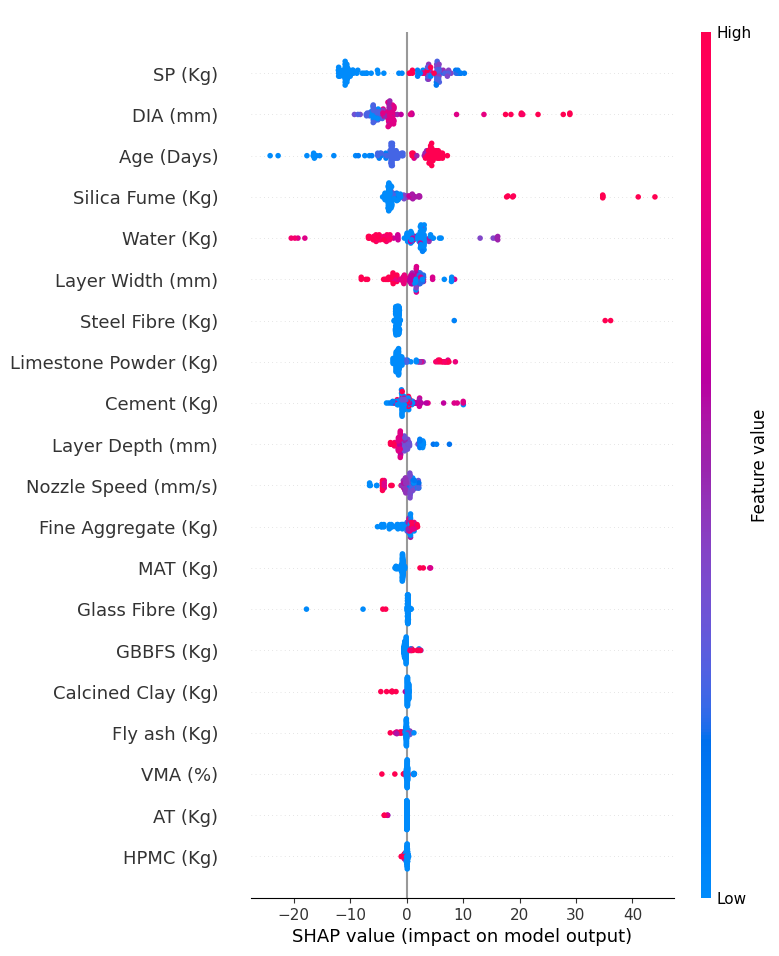

In [38]:
# Plot SHAP summary with minimized height
plt.figure(figsize=(4, 4))  # Adjusted height to minimize the plot size
shap.summary_plot(shap_values, X_test, feature_names=X.columns, show=False)  # Set show=False to prevent auto-display
plt.gca().set_title(" ")  # Optional: Set a title for clarity
plt.savefig("SHAP1.jpg")
#plt.show()

In [39]:
exp=shap.Explainer(best_model.best_estimator_)
shap_values = exp(X_test)
plt.figure(figsize=(3.2, 3.4))
shap.plots.waterfall(shap_values[60], show=False)
plt.tight_layout()
plt.savefig("WATERFALL.jpg")
plt.close()

In [40]:
plt.figure(figsize=(4, 2))
shap.plots.bar(shap_values, show=False)
plt.tight_layout()
plt.savefig("BAR_IMPORTANCE.jpg")
plt.close()

In [41]:
#Partial Dependence Plot (PDP)
for i in X_test.columns:
    fig, ax = plt.subplots(figsize=(3.5, 3.5)) # Create figure and axes objects
    PartialDependenceDisplay.from_estimator(best_model, X_test, [i], ax=ax) # Pass axes to display
    ax.set_xlabel(f"{i}", fontsize=8) # Use ax.set_xlabel instead of plt.xlabel
    ax.set_ylabel("Partial Dependence", fontsize=8) # Use ax.set_ylabel instead of plt.ylabel
    ax.set_title(f" ") # Use ax.set_title instead of plt.title
    plt.tight_layout()
    plt.savefig(f" PDP of {i.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')}.jpg")
    plt.close(fig) # Close the figure objec

/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])
/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])
/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])
/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])
/usr/local/lib/python3.12/dist-p

### Scatter Plot of XGBOOST

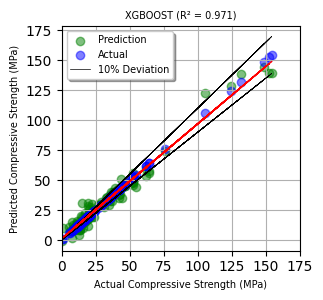

In [42]:
# Calculate the 10% deviation
deviation = 0.10 * y_test
lower_bound = y_test - deviation
upper_bound = y_test + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test, y_pred, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test, y_test, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test, y_pred, 1)
plt.plot(y_test, m * y_test + b, 'r--', lw=1)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)", fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=7)
plt.title(f"XGBOOST (R² = {r2:.3f})", fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_XGBOOST.jpg")
plt.show()

### Scatter Plot of XGBOOST+

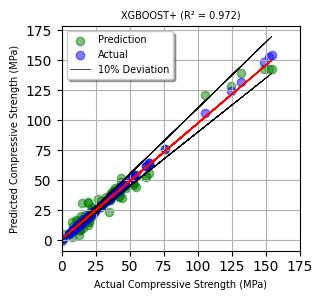

In [43]:
# Calculate the 10% deviation
deviation = 0.10 * y_test
lower_bound = y_test - deviation
upper_bound = y_test + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test, y_predict, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test, y_test, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test, y_predict, 1)
plt.plot(y_test, m * y_test + b, 'r--', lw=1)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)", fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=7)
plt.title(f"XGBOOST+ (R² = {r21:.3f})", fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_XGBOOST+.jpg")
plt.show()

### Scatter Plot of SVM Model

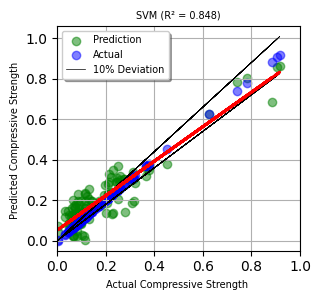

In [44]:
# Calculate the 10% deviation
deviation = 0.10 * ys_test
lower_bound = ys_test - deviation
upper_bound = ys_test + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(ys_test, ys_pred, color='green', alpha=0.5, label='Prediction')
plt.scatter(ys_test, ys_test, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(ys_test, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(ys_test, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(ys_test, ys_pred, 1)
plt.plot(ys_test, m * ys_test + b, 'r--', lw=2)

# Customize the plot
plt.xlabel("Actual Compressive Strength ",fontsize=7)
plt.ylabel("Predicted Compressive Strength ",fontsize=7)
plt.title(f"SVM (R² = {r2s:.3f})",fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 1
interval = 0.2
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_SVM.jpg")
plt.show()

### Scatter Plot of RF Model

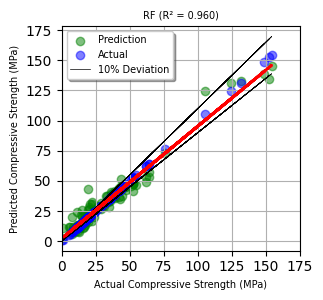

In [45]:
# Calculate the 10% deviation
deviation = 0.10 * y_test
lower_bound = y_test - deviation
upper_bound = y_test + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test, yr_pred, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test, y_test, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test, yr_pred, 1)
plt.plot(y_test, m * y_test + b, 'r--', lw=2)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)", fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=7)
plt.title(f"RF (R² = {r2r:.3f})",fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_RF.jpg")
plt.show()

### Scatter Plot of DT Model

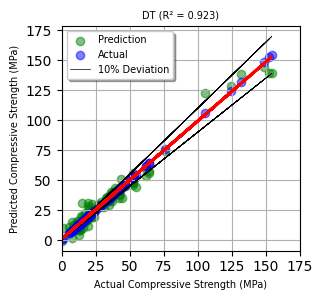

In [46]:
# Calculate the 10% deviation
deviation = 0.10 * y_test
lower_bound = y_test - deviation
upper_bound = y_test + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test, y_pred, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test, y_test, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test, yd_pred, 1)
plt.plot(y_test, m * y_test + b, 'r--', lw=2)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)", fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=7)
plt.title(f"DT (R² = {r2d:.3f})", fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_DT.jpg")
plt.show()

### Scatter Plot of MLR Model

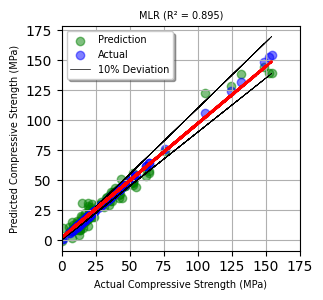

In [47]:
# Calculate the 10% deviation
deviation = 0.10 * y_test
lower_bound = y_test - deviation
upper_bound = y_test + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test, y_pred, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test, y_test, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test, ym_pred, 1)
plt.plot(y_test, m * y_test + b, 'r--', lw=2)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)",fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)",fontsize=7)
plt.title(f"MLR (R² = {r2m:.3f})",fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_MLR.jpg")
plt.show()

### Scatter Plot of KNN Model

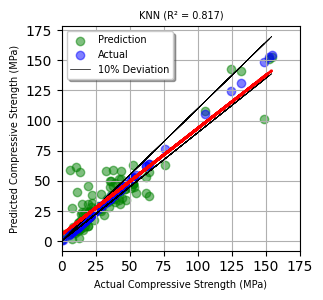

In [48]:
# Calculate the 10% deviation
deviation = 0.10 * y_test
lower_bound = y_test - deviation
upper_bound = y_test + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test, yk_pred, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test, y_test, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test, yk_pred, 1)
plt.plot(y_test, m * y_test + b, 'r--', lw=2)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)", fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=7)
plt.title(f"KNN (R² = {r2k:.3f})", fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_KNN.jpg")
plt.show()

### Material Model

In [49]:
columns_to_remove = ['Nozzle Speed (mm/s)', 'DIA (mm)', 'Layer Depth (mm)', 'Layer Width (mm)']
X_new = imputed_df.drop(columns_to_remove, axis=1).drop('Compressive Strength (MPa)', axis=1).copy()
y_new = imputed_df['Compressive Strength (MPa)'].copy()

# Split the data into training and testing sets
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.3, random_state=42)

grid_model_new=xbt.XGBRegressor()
grid_model_new.fit(X_train_new, y_train_new)

# Use the grid_model to forecast the model
y_predict_new = grid_model_new.predict(X_test_new)

# Evaluate the model
mse_new = mean_squared_error(y_test_new, y_predict_new)
rmse_new = np.sqrt(mse_new)
r2_new = r2_score(y_test_new, y_predict_new)
maer_new = mean_absolute_error(y_test_new, y_predict_new)

print("Mean Absolute Error:", maer_new)
print("Root Mean Squared Error:", rmse_new)
print("R-Squared Score:", r2_new)

Mean Absolute Error: 4.610374470486129
Root Mean Squared Error: 6.578165333116978
R-Squared Score: 0.9478418150822137


#### Scatter Plot of Material Model

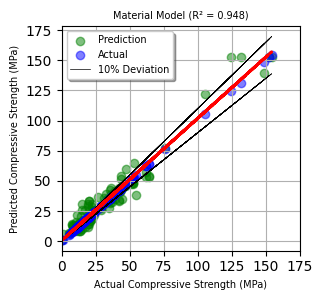

In [50]:
# Calculate the 10% deviation
deviation = 0.10 * y_test_new
lower_bound = y_test_new - deviation
upper_bound = y_test_new + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test_new, y_predict_new, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test_new, y_test_new, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test_new, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test_new, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test_new, y_predict_new, 1)
plt.plot(y_test_new, m * y_test_new + b, 'r--', lw=2)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)", fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=7)
plt.title(f"Material Model (R² = {r2_new:.3f})", fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_Material.jpg")
plt.show()

### Printing Model

In [51]:
X_new = imputed_df[['Nozzle Speed (mm/s)', 'DIA (mm)', 'Layer Depth (mm)', 'Layer Width (mm)']].copy()
y_new = imputed_df['Compressive Strength (MPa)'].copy()

# Split the data into training and testing sets
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.3, random_state=42
)
grid_model_new=xbt.XGBRegressor()
grid_model_new.fit(X_train_new, y_train_new)
# Use the grid_model to forecast the model
y_predict_new = grid_model_new.predict(X_test_new)

# Evaluate the model
mse_new = mean_squared_error(y_test_new, y_predict_new)
rmse_new = np.sqrt(mse_new)
r2_new = r2_score(y_test_new, y_predict_new)
maer_new = mean_absolute_error(y_test_new, y_predict_new)

print("Mean Absolute Error:", maer_new)
print("Root Mean Squared Error:", rmse_new)
print("R-Squared Score:", r2_new)

Mean Absolute Error: 7.080698582121163
Root Mean Squared Error: 11.982427295053917
R-Squared Score: 0.8269376863542055


#### Scatter Plot of Printing Model

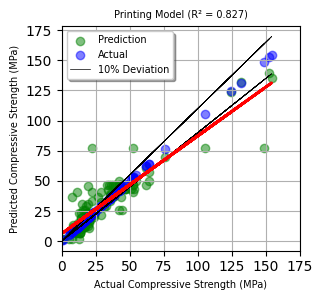

In [52]:
# Calculate the 10% deviation
deviation = 0.10 * y_test_new
lower_bound = y_test_new - deviation
upper_bound = y_test_new + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test_new, y_predict_new, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test_new, y_test_new, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test_new, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test_new, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test_new, y_predict_new, 1)
plt.plot(y_test_new, m * y_test_new + b, 'r--', lw=2)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)", fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=7)
plt.title(f"Printing Model (R² = {r2_new:.3f})", fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_Printing.jpg")
plt.show()

### Exporting Results to excel

In [53]:
#summary = df.describe(include='all')
#summary1=imputed_df.describe(include = 'all')

In [54]:
# Export the summary data frame to an Excel
#summary1.to_excel('summary_data.xlsx', sheet_name='Summary', index=True, header=True)
#summary.to_excel('summary1_dataframe.xlsx', sheet_name='Summary1 Data')
# Export the cleaned data frame to an Excel
#imputed_df.to_excel('imputed_df_dataframe.xlsx', sheet_name='Cleaned Data')

### Residual Curve

Saved: Residuals_XGBOOSTplus.jpg


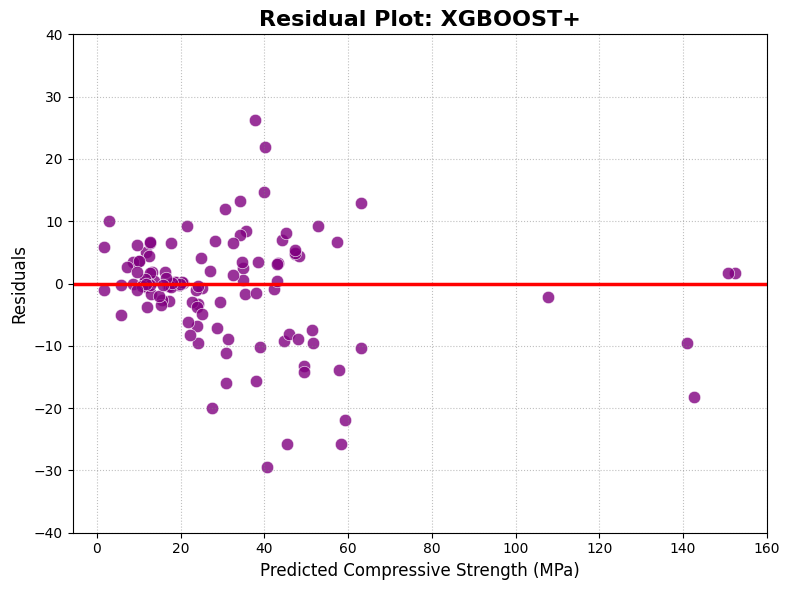

Saved: Residuals_SVM.jpg


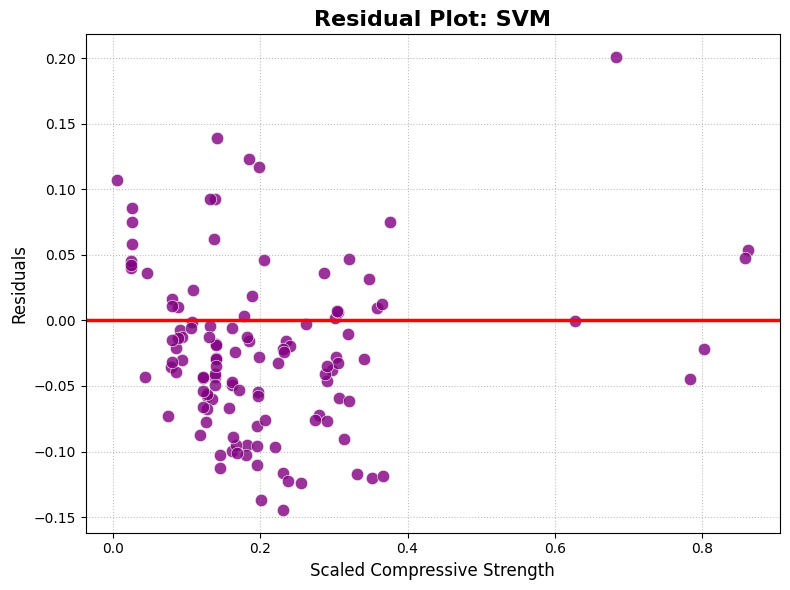

Saved: Residuals_RF.jpg


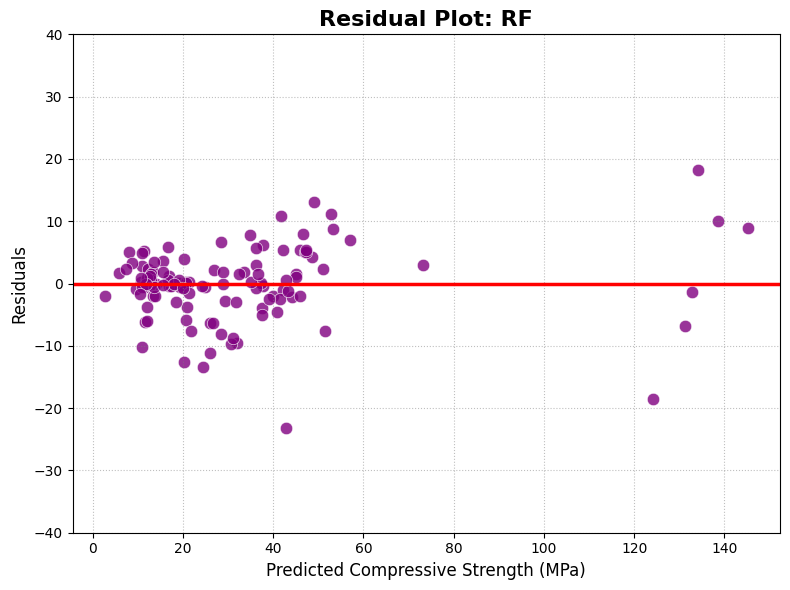

Saved: Residuals_DT.jpg


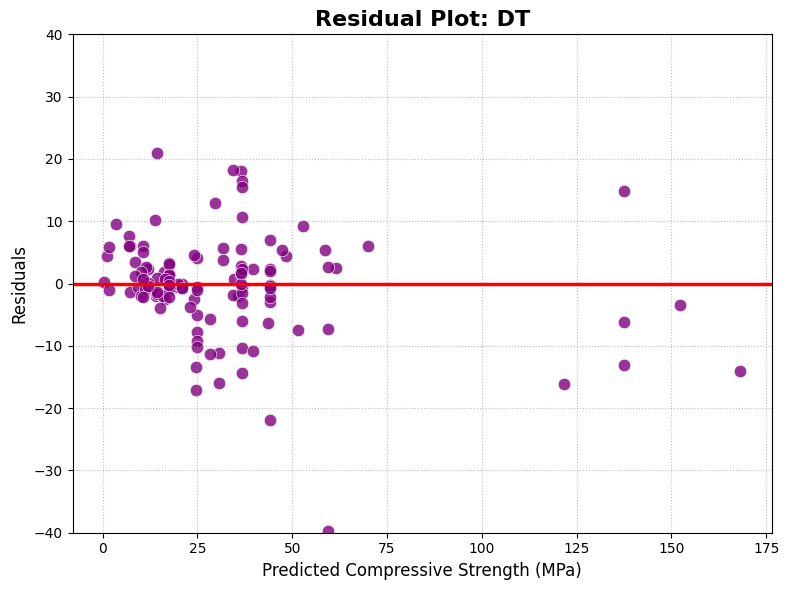

Saved: Residuals_MLR.jpg


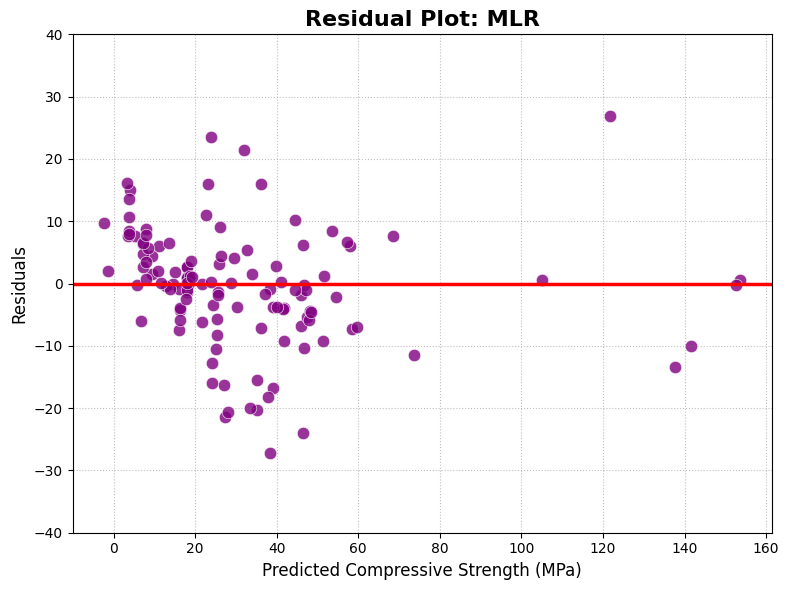

Saved: Residuals_KNN.jpg


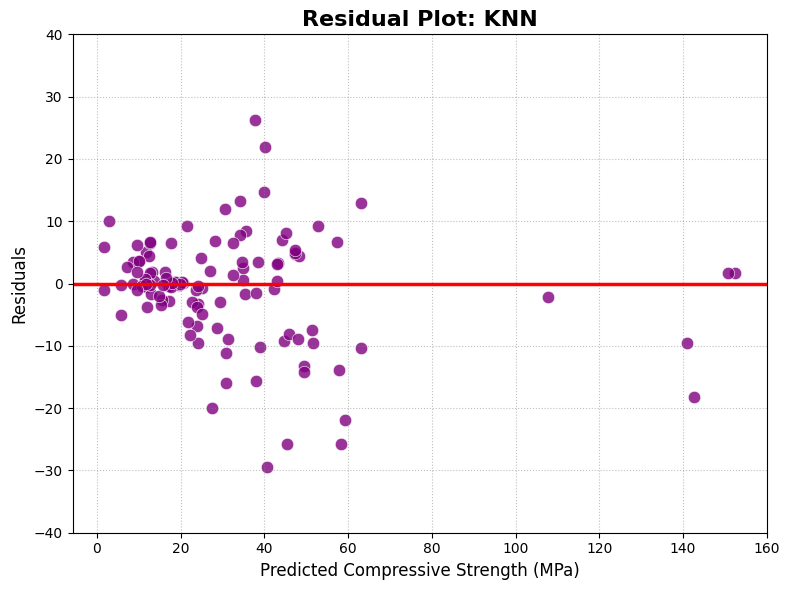

In [65]:
def plot_residuals_individual(name, y_true, y_pred, ylim=None):
    plt.figure(figsize=(8, 6), facecolor='white')
    residuals = y_true - y_pred
    plt.scatter(y_pred, residuals, alpha=0.8, color='purple', edgecolors='white', s=80, linewidth=0.5)
    plt.axhline(0, color='red', linestyle='-', lw=2.5, alpha=1.0)
    plt.title(f'Residual Plot: {name}', fontsize=16, fontweight='bold')

    # Use custom label for SVM, standard label for others
    if name == 'SVM':
        plt.xlabel('Scaled Compressive Strength', fontsize=12)
    else:
        plt.xlabel('Predicted Compressive Strength (MPa)', fontsize=12)

    plt.ylabel('Residuals', fontsize=12)
    if ylim:
        plt.ylim(ylim)
    plt.grid(True, linestyle=':', alpha=0.5, color='gray')

    filename = f"Residuals_{name.replace('+', 'plus').replace(' ', '_')}.jpg"
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    print(f"Saved: {filename}")
    plt.show()
    plt.close()

# Prepare model predictions
model_results = [
    ('XGBOOST+', best_model.predict(X_test)),
    ('SVM', model_svm.predict(Xs_test)),
    ('RF', model_rf.predict(X_test)),
    ('DT', model_dt.predict(X_test)),
    ('MLR', model_ml.predict(X_test)),
    ('KNN', model_kn.predict(X_test))
]

common_resid_ylim = (-40, 40)

for name, y_pred in model_results:
    actuals = ys_test if name == 'SVM' else y_test
    ylim = None if name == 'SVM' else common_resid_ylim
    plot_residuals_individual(name, actuals, y_pred, ylim=ylim)

## LEARNING CURVES

Saved: LC_MSE_XGBOOSt+.jpg


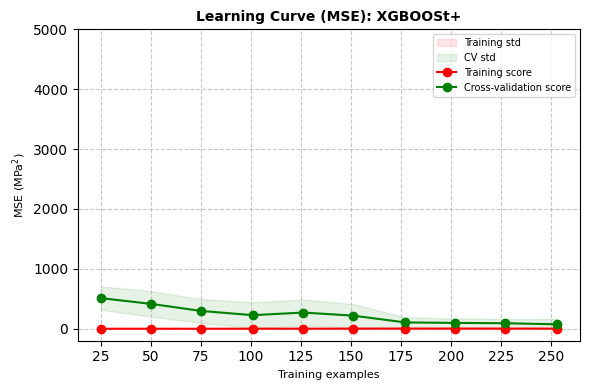

Saved: LC_MSE_SVM.jpg


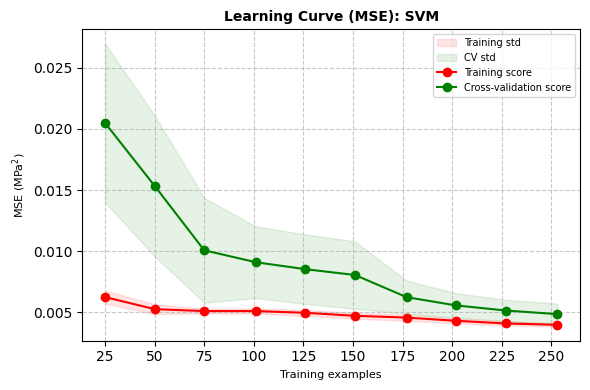

Saved: LC_MSE_RF.jpg


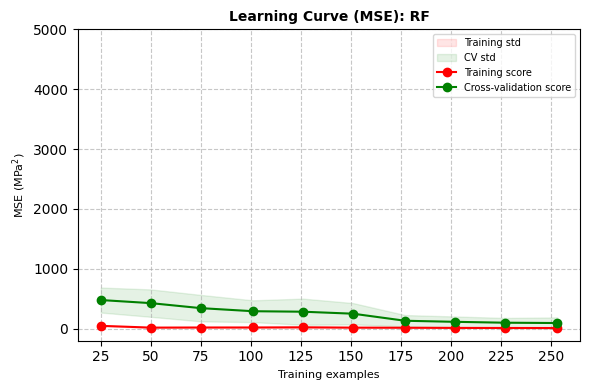

Saved: LC_MSE_DT.jpg


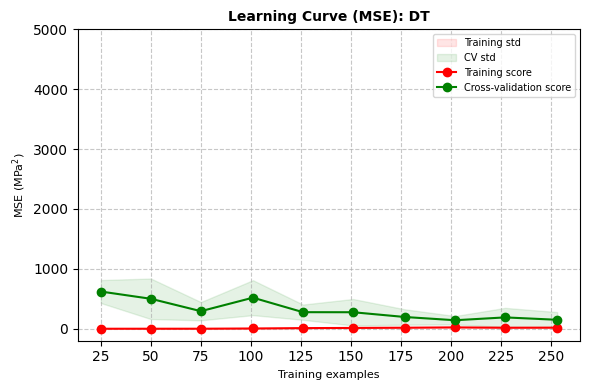

Saved: LC_MSE_MLR.jpg


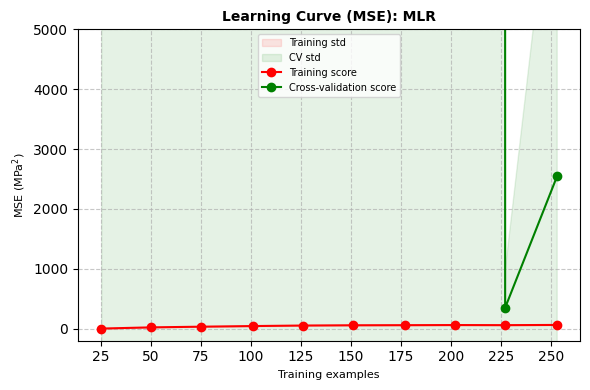

Saved: LC_MSE_KNN.jpg


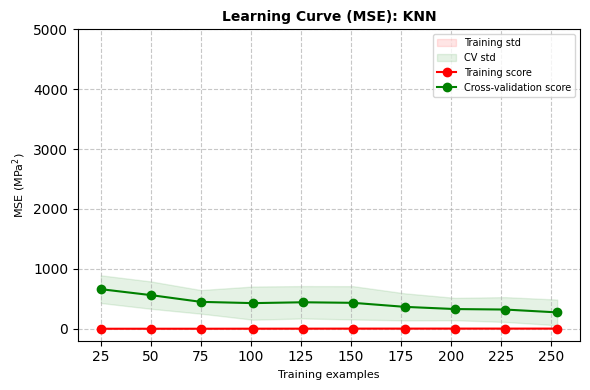

In [56]:
def plot_learning_curve_mse(estimator, title, X_data, y_data, axes, ylim=None, cv=10, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 10)):
    # Using neg_mean_squared_error for MSE
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X_data, y_data, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring='neg_mean_squared_error')

    # Convert negative MSE to positive
    train_scores_mean = (-train_scores).mean(axis=1)
    train_scores_std = (-train_scores).std(axis=1)
    test_scores_mean = (-test_scores).mean(axis=1)
    test_scores_std = (-test_scores).std(axis=1)

    axes.grid(True, linestyle='--', alpha=0.7)
    # Plot fill_between with labels for the legend
    axes.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r", label="Training std")
    axes.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g", label="CV std")

    axes.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    axes.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    # Set x-axis intervals to 25
    axes.xaxis.set_major_locator(ticker.MultipleLocator(25))

    axes.set_title(title, fontsize=10, fontweight='bold')
    axes.set_xlabel("Training examples", fontsize=8)
    axes.set_ylabel("MSE (MPa$^2$)", fontsize=8)
    if ylim:
        axes.set_ylim(*ylim)
    axes.legend(loc="best", fontsize=7)

# Define models to plot
models_mse = [
    (best_model.best_estimator_, "XGBOOSt+", X_train, y_train),
    (model_svm.best_estimator_, "SVM", Xs_train, ys_train),
    (model_rf.best_estimator_, "RF", X_train, y_train),
    (model_dt.best_estimator_, "DT", X_train, y_train),
    (model_ml, "MLR", X_train, y_train),
    (model_kn.best_estimator_, "KNN", X_train, y_train)
]

common_ylim_mse = (-200, 5000)

for name, model_tuple in zip([m[1] for m in models_mse], models_mse):
    est, model_name, x_curr, y_curr = model_tuple

    fig, ax = plt.subplots(figsize=(6, 4))
    ylim = None if model_name == "SVM" else common_ylim_mse
    plot_learning_curve_mse(est, f"Learning Curve (MSE): {model_name}", x_curr, y_curr, ax, ylim=ylim)

    filename = f"LC_MSE_{model_name.replace(' ', '_')}.jpg"
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    print(f"Saved: {filename}")
    plt.show()
    plt.close(fig)

### XGBOOST EPOCH

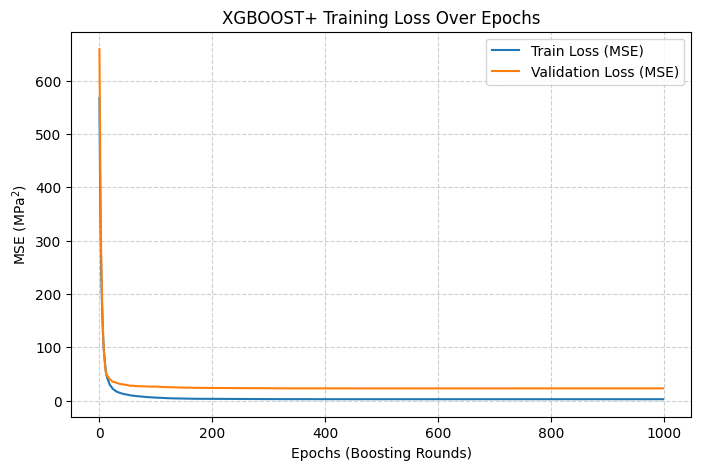

In [57]:


# To get loss over epochs, we must re-fit the best XGBoost model with an eval_set
xgb_best = best_model.best_estimator_

xgb_best.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

results = xgb_best.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)

# Plotting MSE (Internal XGBoost RMSE squared)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_axis, np.square(results['validation_0']['rmse']), label='Train Loss (MSE)')
ax.plot(x_axis, np.square(results['validation_1']['rmse']), label='Validation Loss (MSE)')
ax.legend()
plt.ylabel('MSE (MPa$^2$)')
plt.xlabel('Epochs (Boosting Rounds)')
plt.title('XGBOOST+ Training Loss Over Epochs')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('XGBoost_Loss_Epochs.jpg', dpi=300)
plt.show()

# UPLOAD EXCEL OR CSV FILE TO PREDICT COMPRESSIVE STRENGTH USING THE XGBOOST+ MODEL

In [58]:
print("Please upload your file (.xlsx or .csv) containing the feature columns:")
uploaded = files.upload()

if uploaded:
    file_name = list(uploaded.keys())[0]
    file_content = io.BytesIO(uploaded[file_name])

    if file_name.endswith('.csv'):
        user_df = pd.read_csv(file_content, encoding='latin-1')
    else:
        user_df = pd.read_excel(file_content)

    required_features = X.columns.tolist()

    priority_features = ['Cement (Kg)', 'Water (Kg)', 'Age (Days)', 'Nozzle Speed (mm/s)',
                         'Fine Aggregate (Kg)', 'Silica Fume (Kg)', 'Fly ash (Kg)',
                         'DIA (mm)', 'Layer Depth (mm)', 'Layer Width (mm)']

    other_features = [f for f in required_features if f not in priority_features]
    mapping_order = sorted(priority_features, key=len, reverse=True) + sorted(other_features, key=len, reverse=True)

    model_input = pd.DataFrame(index=user_df.index)
    user_cols = [str(c).strip() for c in user_df.columns]
    user_cols_lower = [c.lower() for c in user_cols]
    used_indices = set()

    for feature in mapping_order:
        found = False
        feature_keyword = feature.lower().split('(')[0].strip()

        # Step A: Exact Match
        for i, u_col in enumerate(user_cols_lower):
            if i not in used_indices and (feature_keyword == u_col or feature.lower() == u_col):
                model_input[feature] = user_df.iloc[:, i]
                used_indices.add(i)
                found = True
                break

        # Step B: Keyword Match
        if not found:
            for i, u_col in enumerate(user_cols_lower):
                if i not in used_indices and feature_keyword in u_col:
                    model_input[feature] = user_df.iloc[:, i]
                    used_indices.add(i)
                    found = True
                    break

        # Step C: Reverse Keyword Match
        if not found:
            for i, u_col in enumerate(user_cols_lower):
                clean_u_col = u_col.split('(')[0].strip()
                if i not in used_indices and len(clean_u_col) > 2 and clean_u_col in feature_keyword:
                    model_input[feature] = user_df.iloc[:, i]
                    used_indices.add(i)
                    found = True
                    break

        if not found:
            model_input[feature] = 0

    model_input = model_input[required_features].fillna(0)
    predictions = best_model.predict(model_input)
    user_df['PREDICTED_Compressive_Strength_MPa'] = predictions

    output_file = 'Predictions_Output.xlsx'
    user_df.to_excel(output_file, index=False)
    print(f"\nProcessing Complete! Downloading {output_file}...")
    files.download(output_file)
else:
    print('No file uploaded.')

Please upload your file (.xlsx or .csv) containing the feature columns:


Saving Predictions_Output.xlsx to Predictions_Output.xlsx

Processing Complete! Downloading Predictions_Output.xlsx...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>